# Week 8 – Day 2

# Exploratory Data Analysis & Feature Engineering

## Objective

Perform a professional Exploratory Data Analysis (EDA) on five Indian large-cap stocks and engineer technical indicator features for machine learning.

### Stocks

- Reliance
- TCS
- Infosys
- HDFC Bank
- ICICI Bank


In [20]:
# Numerical computations
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Technical indicators
import yfinance as yf

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [21]:
# Load raw stock dataset

data = pd.read_csv(
    "../data/raw_stock_data.csv",
    header=[0,1],
    index_col=0
)

# Convert index to datetime

data.index = pd.to_datetime(data.index)

# Display first rows

data.head()

Ticker     ICICIBANK.NS                                                \
Price              Open        High         Low       Close    Volume   
Date                                                                    
2019-01-01   348.786163  351.970091  343.865522  350.957031   7759872   
2019-01-02   348.786150  354.961058  347.628342  351.777130  18243156   
2019-01-03   352.163093  354.382191  349.316832  350.474640  12884409   
2019-01-04   349.123861  355.829414  345.457488  352.356049  22896026   
2019-01-07   354.575150  357.952056  353.658549  354.768127  12719847   

Ticker     RELIANCE.NS                                                ...  \
Price             Open        High         Low       Close    Volume  ...   
Date                                                                  ...   
2019-01-01  498.077624  498.985034  491.371654  496.196381   9746670  ...   
2019-01-02  493.319235  498.852220  487.343625  489.733887  15628818  ...   
2019-01-03  490.220755  493.363478  482.518879  483.691864  16288287  ...   
2019-01-04  485.750155  488.870748  478.535167  486.303436  18516544  ...   
2019-01-07  489.999414  495.067613  487.343578  489.003479  12060290  ...   

Ticker           TCS.NS                                                  \
Price              Open         High          Low        Close   Volume   
Date                                                                      
2019-01-01  1555.421809  1566.906991  1546.397737  1561.000366  1094883   
2019-01-02  1562.805421  1586.965286  1558.703569  1577.818237  2100463   
2019-01-03  1574.290569  1595.579138  1553.042959  1558.662476  2611668   
2019-01-04  1558.703259  1559.687663  1510.301421  1539.711670  4280862   
2019-01-07  1551.976353  1565.922646  1543.116315  1556.980591  1856423   

Ticker         INFY.NS                                               
Price             Open        High         Low       Close   Volume  
Date                                                                 
2019-01-01  538.386137  542.744035  532.847111  541.725830  2943390  
2019-01-02  542.499538  549.016049  539.282001  544.983948  7416655  
2019-01-03  547.387039  551.459860  540.137400  545.065552  6827249  
2019-01-04  547.183436  548.934769  530.281231  538.467590  7889310  
2019-01-07  541.684990  548.690220  538.834016  547.142578  8046340  

[5 rows x 25 columns]

# Dataset Overview


In [22]:
# Dataset information

print(data.shape)

print()

print(data.info())

(1480, 25)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1480 entries, 2019-01-01 to 2024-12-30
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   (ICICIBANK.NS, Open)    1480 non-null   float64
 1   (ICICIBANK.NS, High)    1480 non-null   float64
 2   (ICICIBANK.NS, Low)     1480 non-null   float64
 3   (ICICIBANK.NS, Close)   1480 non-null   float64
 4   (ICICIBANK.NS, Volume)  1480 non-null   int64  
 5   (RELIANCE.NS, Open)     1480 non-null   float64
 6   (RELIANCE.NS, High)     1480 non-null   float64
 7   (RELIANCE.NS, Low)      1480 non-null   float64
 8   (RELIANCE.NS, Close)    1480 non-null   float64
 9   (RELIANCE.NS, Volume)   1480 non-null   int64  
 10  (HDFCBANK.NS, Open)     1480 non-null   float64
 11  (HDFCBANK.NS, High)     1480 non-null   float64
 12  (HDFCBANK.NS, Low)      1480 non-null   float64
 13  (HDFCBANK.NS, Close)    1480 non-null   float64
 14  (HDFCBANK.

In [23]:

missing = data.isnull().sum()

missing


Ticker        Price 
ICICIBANK.NS  Open      0
              High      0
              Low       0
              Close     0
              Volume    0
RELIANCE.NS   Open      0
              High      0
              Low       0
              Close     0
              Volume    0
HDFCBANK.NS   Open      0
              High      0
              Low       0
              Close     0
              Volume    0
TCS.NS        Open      0
              High      0
              Low       0
              Close     0
              Volume    0
INFY.NS       Open      0
              High      0
              Low       0
              Close     0
              Volume    0
dtype: int64

# Closing Price Visualization

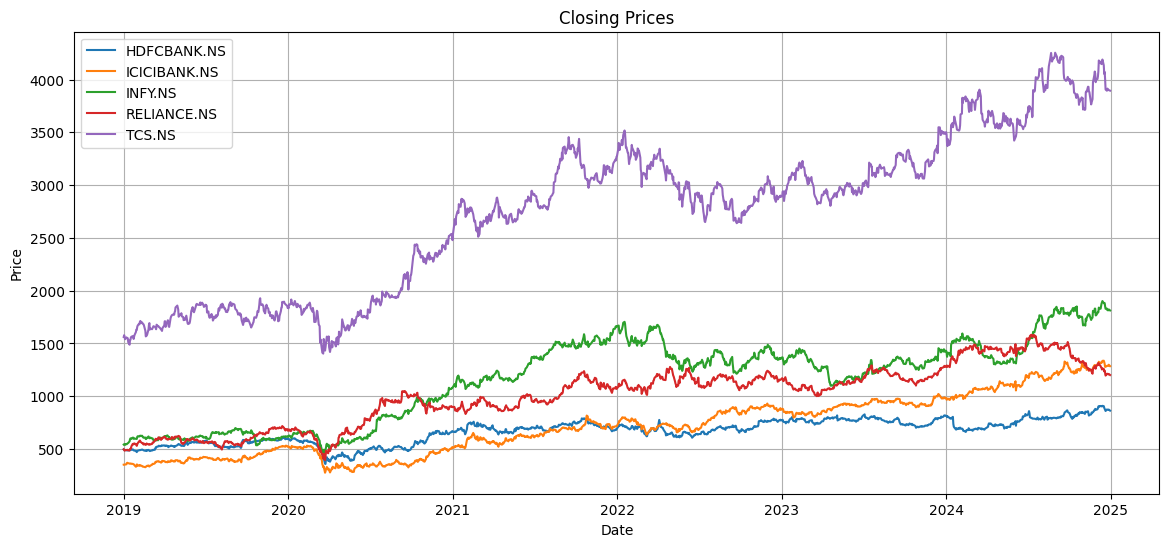

In [24]:
plt.figure(figsize=(14,6))

for stock in data.columns.levels[0]:

    plt.plot(
        data[stock]["Close"],
        label=stock
    )

plt.title("Closing Prices")

plt.xlabel("Date")

plt.ylabel("Price")

plt.legend()

plt.grid()

plt.savefig(
    "../images/closing_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Daily Returns

In [25]:
# Daily returns

returns = pd.DataFrame()

for stock in data.columns.levels[0]:

    returns[stock] = data[stock]["Close"].pct_change()

returns.head()

,HDFCBANK.NS,ICICIBANK.NS,INFY.NS,RELIANCE.NS,TCS.NS
Date,,,,,
2019-01-01,NaN,NaN,NaN,NaN,NaN
2019-01-02,-0.009124,0.002337,0.006014,-0.013024,0.010774
2019-01-03,-0.007846,-0.003703,0.000150,-0.012337,-0.012141
2019-01-04,0.002675,0.005368,-0.012105,0.005399,-0.012158
2019-01-07,0.001511,0.006846,0.016111,0.005552,0.011216


<Figure size 1200x600 with 0 Axes>

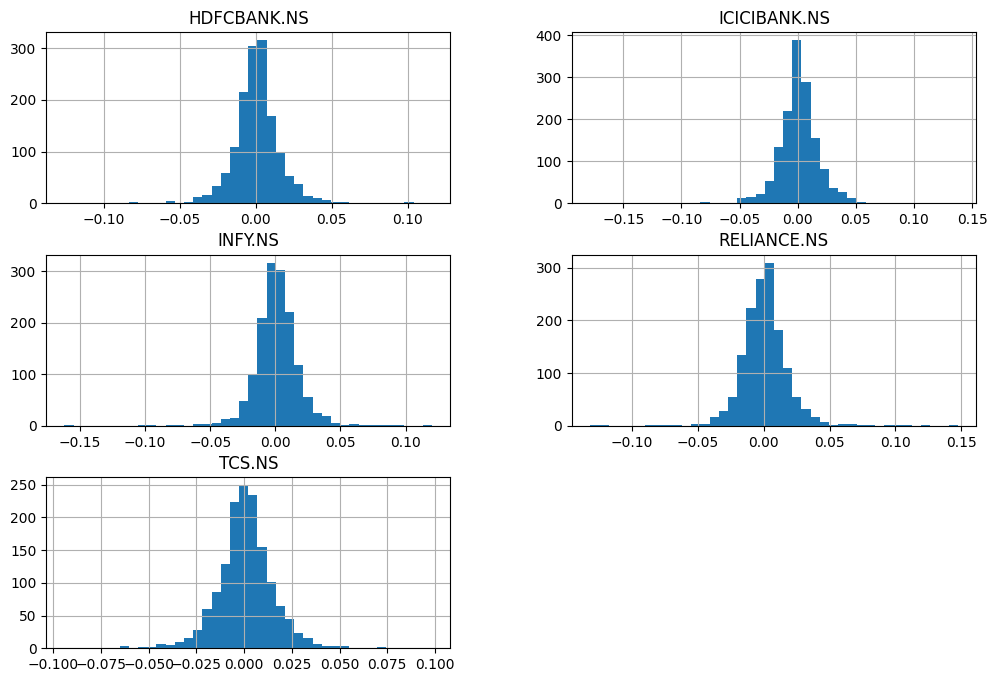

In [26]:
plt.figure(figsize=(12,6))

returns.hist(
    bins=40,
    figsize=(12,8)
)

plt.savefig(
    "../images/returns_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

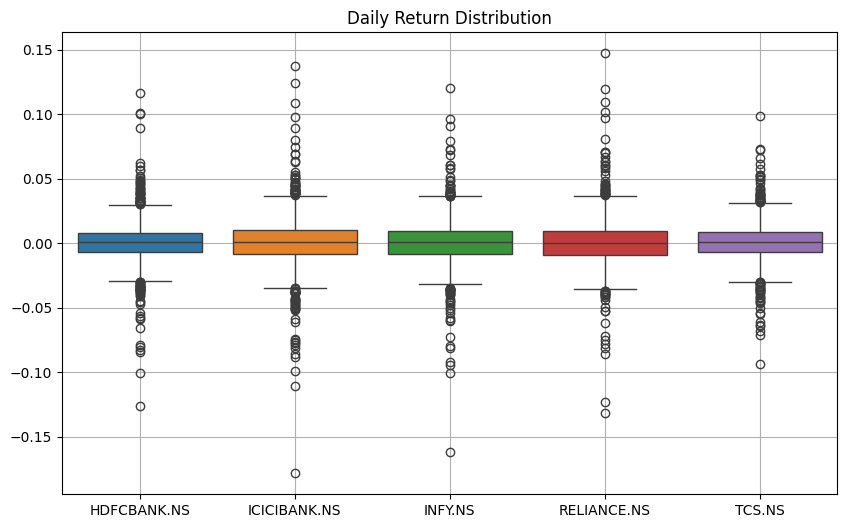

In [27]:
plt.figure(figsize=(10,6))

sns.boxplot(data=returns)

plt.title("Daily Return Distribution")

plt.grid()

plt.savefig(
    "../images/boxplot_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

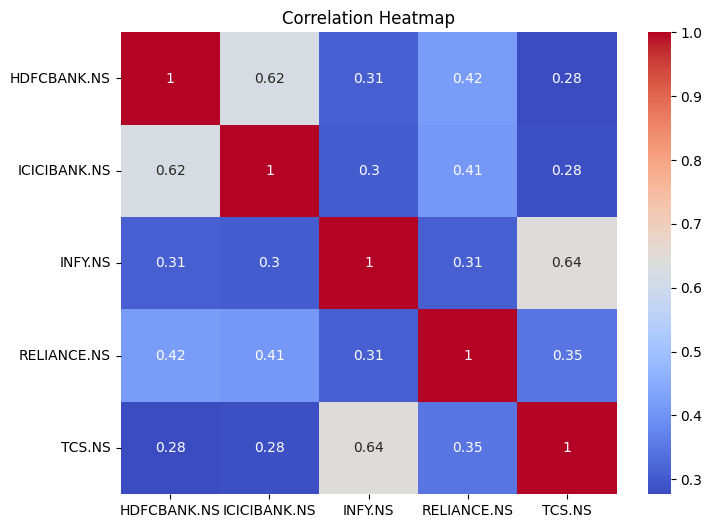

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    returns.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Technical Indicator Feature Engineering

In [29]:
# Use Reliance as example

stock = data["RELIANCE.NS"].copy()

In [30]:
# Simple Moving Average

stock["SMA_10"] = stock["Close"].rolling(10).mean()

stock["SMA_20"] = stock["Close"].rolling(20).mean()

stock["SMA_50"] = stock["Close"].rolling(50).mean()

In [31]:
# Exponential Moving Average

stock["EMA_10"] = stock["Close"].ewm(span=10).mean()

stock["EMA_20"] = stock["Close"].ewm(span=20).mean()

In [32]:
# Daily Return

stock["Return"] = stock["Close"].pct_change()

In [33]:
# Lag Features

stock["Lag_1"] = stock["Return"].shift(1)

stock["Lag_5"] = stock["Return"].shift(5)

stock["Lag_21"] = stock["Return"].shift(21)

In [34]:
# Rolling Volatility

stock["Volatility_20"] = stock["Return"].rolling(20).std()

In [35]:
# RSI

delta = stock["Close"].diff()

gain = delta.clip(lower=0)

loss = -delta.clip(upper=0)

avg_gain = gain.rolling(14).mean()

avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

stock["RSI"] = 100 - (100 / (1 + rs))

In [36]:
# MACD

ema12 = stock["Close"].ewm(span=12).mean()

ema26 = stock["Close"].ewm(span=26).mean()

stock["MACD"] = ema12 - ema26

stock["Signal"] = stock["MACD"].ewm(span=9).mean()

In [37]:
stock.to_csv("../data/features.csv")

print("Features saved successfully.")

Features saved successfully.


# Engineered Features

The following features were created:

1. SMA_10
2. SMA_20
3. SMA_50
4. EMA_10
5. EMA_20
6. Daily Return
7. Lag_1
8. Lag_5
9. Lag_21
10. Rolling Volatility
11. RSI
12. MACD
13. Signal Line

# Conclusion

The dataset was explored using presentation-quality visualizations, including price trends, return distributions, and stock correlations. Multiple technical indicators and lag-based features were engineered to support the machine learning models in the upcoming stages of the capstone project. The processed feature dataset has been saved as `features.csv` and is ready for further modeling.